In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath(".."))

from src.constants import N_COMPONENTS, REDUCTION_METHOD, ASSET_COLS, COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, apply_dim_reduction, loading_table, train_test_split
from src.hmm_model import HMMRegimeModel
from src.plots import (plot_regime_states, plot_regime_probs, plot_regime_nber, _fmt_matrix)
from src.portfolio import (estimate_regime_moments, optimize_regimes,
                            shrinkage_diagnostics)
from src.metrics import compute_metrics
from src.backtest import run_backtest, print_metrics_table

# Backward-compat wrappers
def fit_hmm(X, K=2, n_iter=200, n_restarts=10, tol=1e-6, random_state=42):
    return HMMRegimeModel(n_states=K, n_iter=n_iter, n_restarts=n_restarts,
                           tol=tol, random_state=random_state).fit(X)

def get_smoothed_probs(model, X): return model.smoothed_probs(X)
def get_filtered_probs(model, X): return model.filtered_probs(X)

plot_hmm_states      = lambda d, s, title="HMM Regime States": plot_regime_states(d, s, title)
plot_hmm_state_probs = lambda d, p, title="HMM State Probabilities": plot_regime_probs(d, p, title)

## Description

- Goal: implement GMV and MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix (with shrinkage)
- Methodology:
  - Step 1: Use 15 macroeconomic indicators with dimentionality reduction techniques (PCA and PLS) to classify states (K=2)
  - Step 2: Estimate state-conditional mean and covariance (Ledoit-Wolf shrinkage for covariance and Bayes-Stein for means)
  - Step 3: Implement GMV and MVO for each state to determine optimal portfolio weights
  - Step 4: Export .csv files containing the target weights to be used for backtesting



## Data preparation

Standardize macroeconomic indicators and prepare train/test arrays.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,continuing_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply,dollar_index
Date,,,,,,,,,,,,,,,
1990-02-28,0.766740,0.213257,-0.176815,0.086523,0.140235,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.971936,-0.116878,0.017130
1990-03-31,0.370899,-0.142952,-0.176815,-0.056857,0.082572,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.385261,-0.207448,1.046560
1990-04-30,-0.367268,0.582737,0.366229,0.272514,0.167186,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.409511,-0.174649,-0.009542
1990-05-31,0.183034,-0.438133,0.004200,-0.054564,0.122786,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.370488,-0.904505,-0.734113
1990-06-30,0.216958,-0.097920,-0.357829,0.083436,0.050709,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.370905,-0.083910,-0.013835


In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   continuing_claims       431 non-null    float64
 5   cpi                     431 non-null    float64
 6   oil_price               431 non-null    float64
 7   vix                     431 non-null    float64
 8   credit_spread           431 non-null    float64
 9   yield_curve_slope       431 non-null    float64
 10  fed_funds_rate          431 non-null    float64
 11  consumer_sentiment      431 non-null    float64
 12  housing_starts          431 non-null    float64
 13  m2_money_supply         431 non-null    float64
 14  dollar_index            431 non-nu

In [4]:
# asset data 
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index_fund     431 non-null    float64
 1   treasury_fund  431 non-null    float64
 2   gold_fund      431 non-null    float64
dtypes: float64(3)
memory usage: 13.5 KB


In [5]:

# split and standardize macro data using robust scaler
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)


In [6]:
# train data for PLS 
Y_train = asset_df.loc[dates_train, ASSET_COLS].values

### Data dimensionality reduction


── PCA summary ──
  Input dimensions  : 15
  Components kept   : 5  (threshold = 85%)
  Variance explained: 82.1%

  Per-component breakdown:
    PC1: 44.9%  cumulative 44.9%  █████████████████
    PC2: 22.0%  cumulative 66.9%  ████████
    PC3:  6.4%  cumulative 73.3%  ██
    PC4:  5.1%  cumulative 78.4%  ██
    PC5:  3.7%  cumulative 82.1%  █

  Projected train shape : (431, 5)


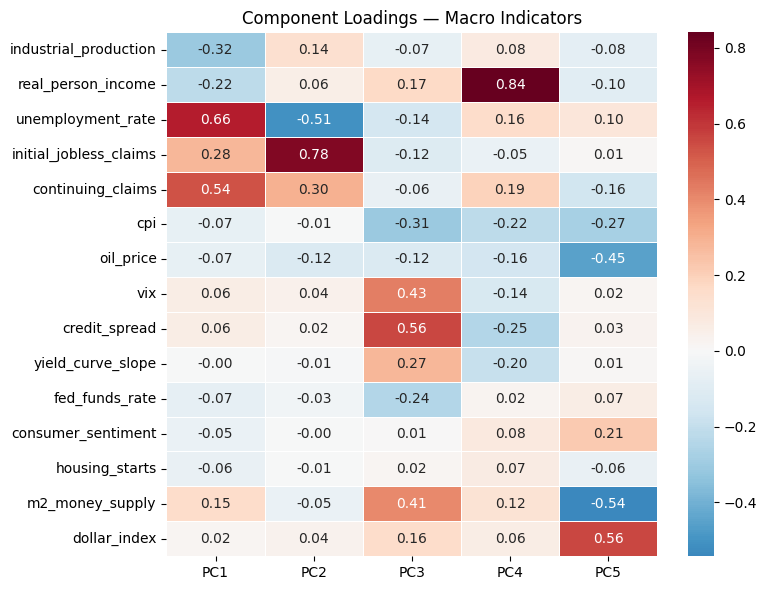

,PC1,PC2,PC3,PC4,PC5
industrial_production,-0.315169,0.136588,-0.069248,0.075304,-0.082776
real_person_income,-0.215720,0.055688,0.167748,0.841148,-0.097194
unemployment_rate,0.658866,-0.507020,-0.143152,0.159169,0.101060
initial_jobless_claims,0.283134,0.780911,-0.115395,-0.052534,0.011924
continuing_claims,0.535383,0.298170,-0.057772,0.194646,-0.158969
cpi,-0.068211,-0.006901,-0.306884,-0.222067,-0.274867
oil_price,-0.070292,-0.120084,-0.123049,-0.156983,-0.453607
vix,0.063464,0.044684,0.427994,-0.135428,0.017409
credit_spread,0.063300,0.017236,0.559525,-0.245439,0.026473
yield_curve_slope,-0.002262,-0.011050,0.274523,-0.195525,0.010903


In [7]:
X_train_reduced, X_test_reduced, reducer = apply_dim_reduction(X_train, X_test, 
                                                   method=REDUCTION_METHOD, 
                                                   Y_train=Y_train,
                                                   n_components=N_COMPONENTS)
# Loadings heatmap
loadings = loading_table(reducer, macro_df.columns.tolist())
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('Component Loadings — Macro Indicators')
plt.tight_layout()
plt.savefig(f'../outputs/figures/{REDUCTION_METHOD}_loadings_hmm.png', dpi=150,
            bbox_inches='tight')
plt.show()
display(loadings)

## Model fitting

In [8]:
model = fit_hmm(X_train_reduced, 
                K=2, 
                n_iter=200, 
                n_restarts=10, 
                tol=1e-6, 
                random_state=42)


Model is not converging.  Current: -1003.2581409265274 is not greater than -1003.2581381897638. Delta is -2.736763576649537e-06
Model is not converging.  Current: -1003.2581416197074 is not greater than -1003.2581382659272. Delta is -3.3537802437422215e-06
Model is not converging.  Current: -1003.2581416192133 is not greater than -1003.2581382657496. Delta is -3.3534637395860045e-06
Model is not converging.  Current: -1003.2581404253322 is not greater than -1003.2581390412695. Delta is -1.3840626706951298e-06
Model is not converging.  Current: -1003.2581416409273 is not greater than -1003.2581382990184. Delta is -3.3419089504604926e-06
Model is not converging.  Current: -1003.2581409382482 is not greater than -1003.2581382090096. Delta is -2.7292385311739054e-06
Model is not converging.  Current: -1003.2581411042457 is not greater than -1003.2581387170957. Delta is -2.3871500616223784e-06
Model is not converging.  Current: -1003.2581397344458 is not greater than -1003.2581390218493. De

Best log-likelihood (per sample): -1003.2581
Transition matrix:
[[0.72902838 0.27097162]
 [0.03152797 0.96847203]]
State durations (months): ['3.7', '31.7']
State 0 = Expansion  (PC1 mean: -0.091)
State 1 = Recession  (PC1 mean: -0.063)


## Extracting results

In [9]:
smoothed_probs_train = get_smoothed_probs(model, X_train_reduced)
print("Smoothed probs shape:", smoothed_probs_train.shape)
print("Sum to 1:", np.allclose(smoothed_probs_train.sum(axis=0), 1.0))

Smoothed probs shape: (2, 431)
Sum to 1: True


In [10]:
filtered_probs_train = get_filtered_probs(model, X_train_reduced)
print("Filtered probs shape:", filtered_probs_train.shape)
print("Sum to 1:", np.allclose(filtered_probs_train.sum(axis=0), 1.0))

Filtered probs shape: (2, 431)
Sum to 1: True


In [11]:
states_sequence = model.predict(X_train_reduced)
print("State counts:", np.unique(states_sequence, return_counts=True))

State counts: (array([0, 1]), array([ 41, 390]))


In [12]:
states_sequence_series = pd.Series(states_sequence, index=dates_train, name="HMM State")
states_sequence_series.value_counts()

HMM State
1    390
0     41
Name: count, dtype: int64

### Transition matrix

In [13]:
pd.DataFrame(model.transmat_,
             columns=[f"State {i}" for i in range(model.n_components)],
             index=[f"State {i}" for i in range(model.n_components)])

,State 0,State 1
State 0,0.729028,0.270972
State 1,0.031528,0.968472


In [14]:
print(f"Average duration in each state (expected number of consecutive months):")
for i, persistent_prob in enumerate(model.transmat_.diagonal()):
    print(f"State {i}: {1 / (1 - persistent_prob):.2f} months")

Average duration in each state (expected number of consecutive months):
State 0: 3.69 months
State 1: 31.72 months


### Conditional means and covariance matrices

In [15]:
if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]

pd.DataFrame(
    model.means_,
    columns=component_names,
    index=['State 0', 'State 1']
).T

,State 0,State 1
PC1,-0.090673,-0.063105
PC2,-0.145581,0.005084
PC3,0.593932,-0.068926
PC4,-0.181459,0.021086
PC5,-0.187555,0.021766


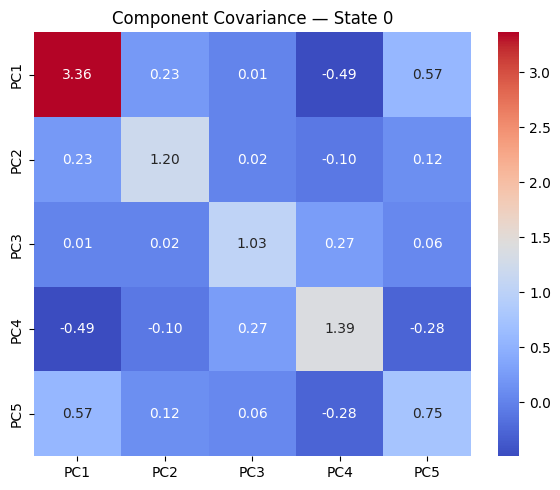

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[0], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('Component Covariance — State 0')
plt.tight_layout()
plt.show()


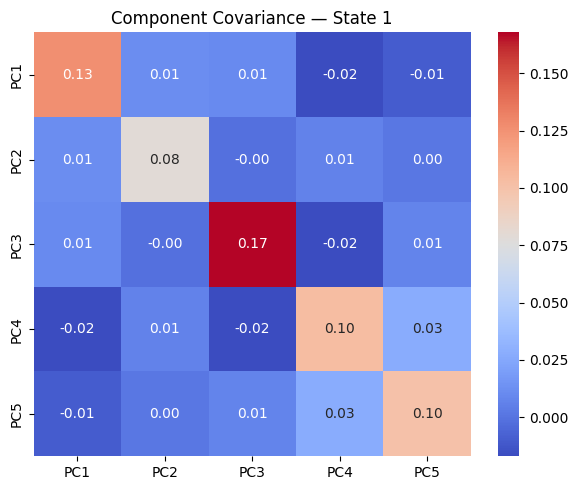

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[1], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('Component Covariance — State 1')
plt.tight_layout()
plt.show()


## Plotting results

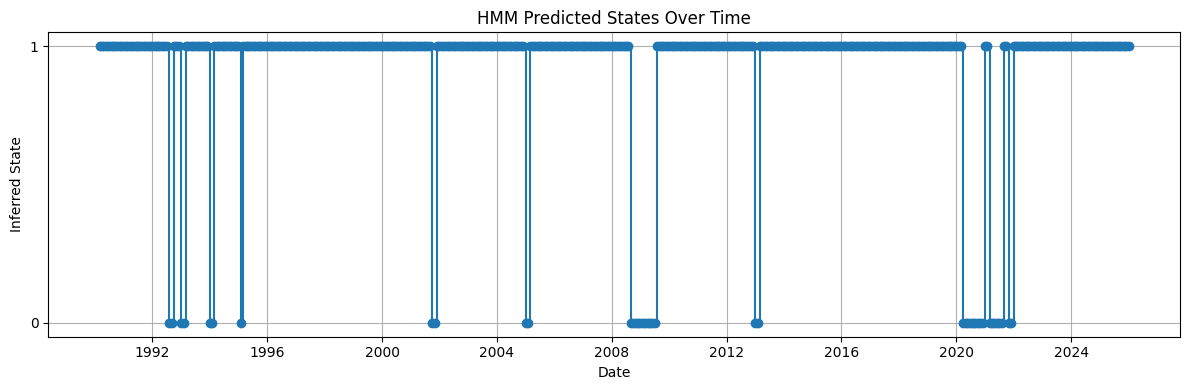

In [18]:
plot_hmm_states(dates_train, states_sequence, title="HMM Predicted States Over Time")
plt.show()

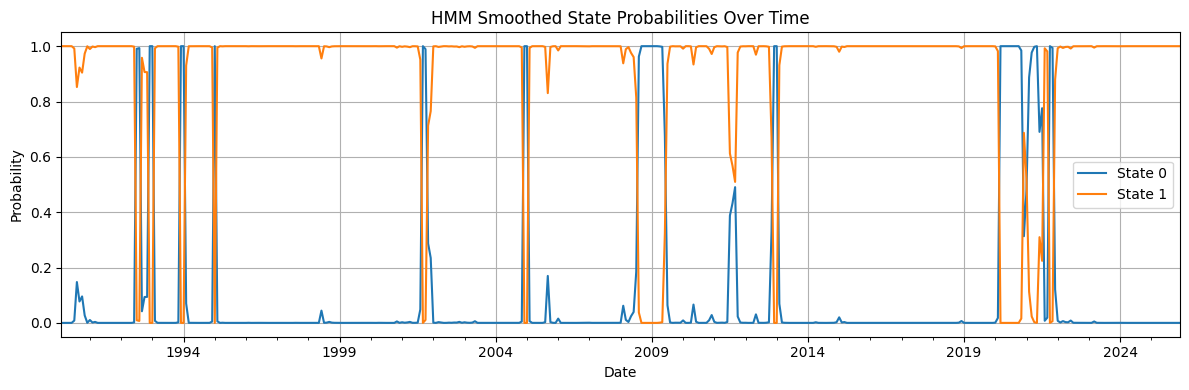

In [19]:
plot_hmm_state_probs(dates_train, smoothed_probs_train,
                     title="HMM Smoothed State Probabilities Over Time")
plt.show()

In [20]:
# number of instances with probabilities between 0.2 and 0.8
p0 = filtered_probs_train[0, :]
((p0 >= 0.3) & (p0 <= 0.7)).sum().item()

5

In [21]:
macro_df_expanded = macro_df.copy()
macro_df_expanded["HMM State"] = states_sequence

In [22]:
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.copy()
asset_df_expanded["HMM State"] = macro_df_expanded["HMM State"]

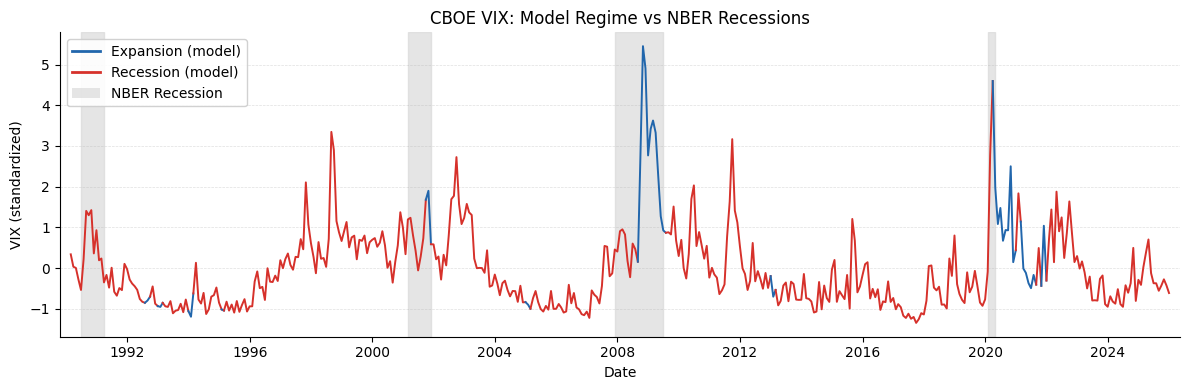

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='HMM State',
    recession_state=1,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

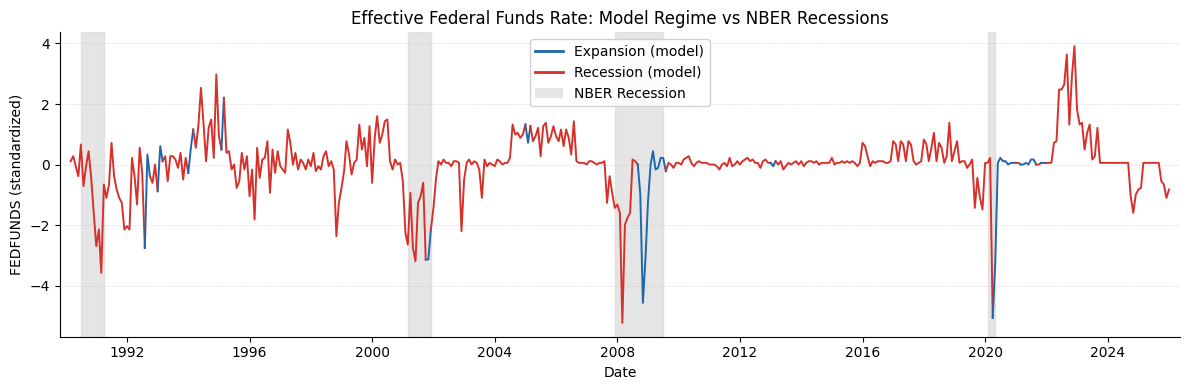

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='fed_funds_rate', state_col='HMM State',
    recession_state=1,
    title='Effective Federal Funds Rate: Model Regime vs NBER Recessions',
    ylabel='FEDFUNDS (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

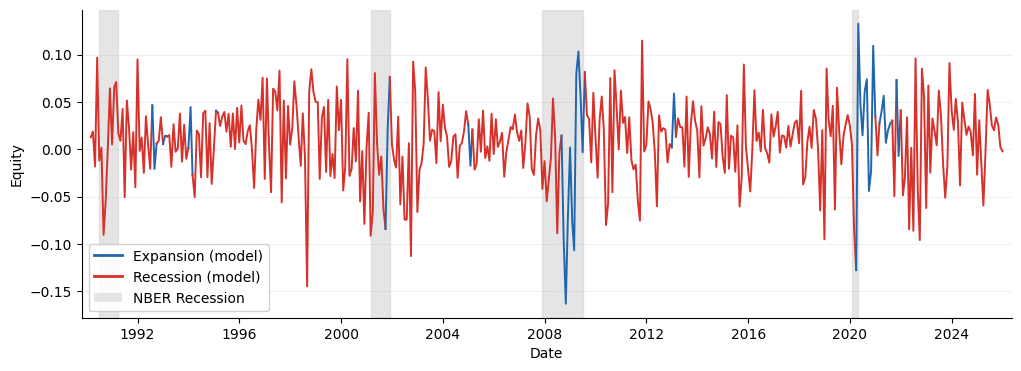

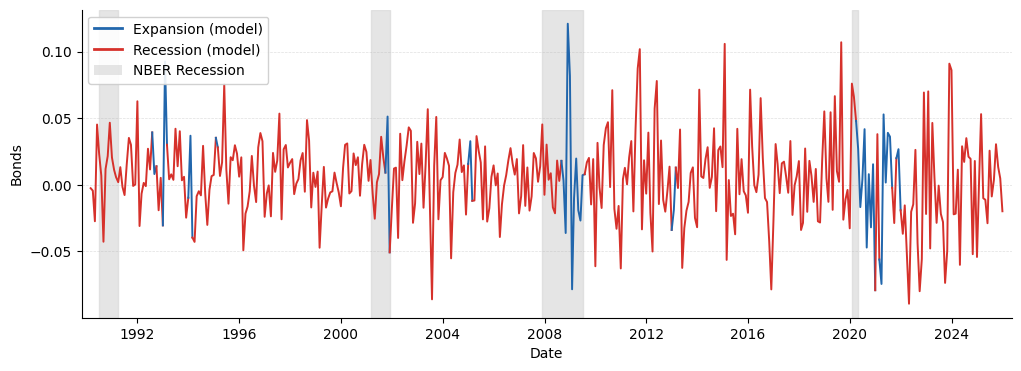

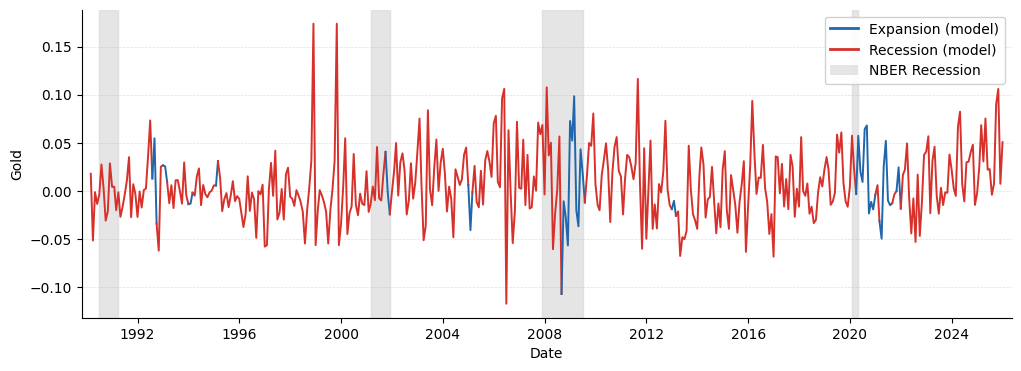

In [25]:
for col in asset_df.columns:
    plot_regime_nber(asset_df_expanded, series_name=col, state_col="HMM State", ax=None)
    plt.show()

## Portfolio optimization

Regime-conditional optimal weights using Ledoit-Wolf and Bayes-Stein estimated on the training set.

In [26]:
market_train, market_test = train_test_split(asset_df_expanded)
print("Last train date:", market_train.index[-1])
print("First test date:", market_test.index[0])

Last train date: 2018-09-30 00:00:00
First test date: 2018-10-31 00:00:00


In [27]:
ASSET_NAMES = market_train.columns[:-1].tolist()  # Exclude 'HMM State' column

In [28]:
# regime-conditional moments with shrinkage methods
moments = estimate_regime_moments(market_train,
                                  asset_cols=ASSET_NAMES,
                                  state_col="HMM State")


── Regime 0  (24 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample -5.86%  →  BS +5.79%
    Bonds           : sample +15.38%  →  BS +9.91%
    Gold            : sample +4.89%  →  BS +4.84%
  Bayes-Stein φ  : 0.7051  (heavy shrinkage)
  Ledoit-Wolf α  : 0.9344
  Implied annual volatilities (shrunk Σ):
    Equity          : 18.01%
    Bonds           : 17.55%
    Gold            : 17.54%

── Regime 1  (320 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample +11.90%  →  BS +10.73%
    Bonds           : sample +7.03%  →  BS +7.58%
    Gold            : sample +4.82%  →  BS +4.82%
  Bayes-Stein φ  : 0.9428  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1794
  Implied annual volatilities (shrunk Σ):
    Equity          : 13.11%
    Bonds           : 9.95%
    Gold            : 12.33%


In [29]:
shrinkage_diagnostics(moments, asset_cols=ASSET_NAMES)


── Ledoit-Wolf shrinkage effect (shrunk Σ − raw Σ) ──

Regime 0  (α = 0.9344):
          Equity   Bonds    Gold
  Equity-0.00148-0.00036 0.00050
   Bonds-0.00036 0.00056 0.00027
    Gold 0.00050 0.00027 0.00058

Regime 1  (α = 0.1794):
          Equity   Bonds    Gold
  Equity-0.00006 0.00003 0.00002
   Bonds 0.00003 0.00007-0.00004
    Gold 0.00002-0.00004-0.00002


In [30]:
# asset_names = market_train.columns[:-1]

print("=" * 55)
print("Regime-Conditional Optimal Weights")
print("=" * 55)
results = optimize_regimes(moments, ASSET_NAMES, rf=0.0, long_only=True)

print("\n" + "=" * 55)
print("=" * 55)
plt.show()


Regime-Conditional Optimal Weights

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +6.85%
  Volatility     (ann.) : 10.18%
  Sharpe ratio          : 0.6727
  Weights:
    Equity        : 0.3207  (32.1%)
    Bonds         : 0.3359  (33.6%)
    Gold          : 0.3434  (34.3%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +7.56%
  Volatility     (ann.) : 10.69%
  Sharpe ratio          : 0.7067
  Weights:
    Equity        : 0.2687  (26.9%)
    Bonds         : 0.4861  (48.6%)
    Gold          : 0.2452  (24.5%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +7.86%
  Volatility     (ann.) : 6.59%
  Sharpe ratio          : 1.1918
  Weights:
    Equity        : 0.3089  (30.9%)
    Bonds         : 0.4382  (43.8%)
    Gold          : 0.2528  (25.3%)

── max_sharpe  |  Regime 1 ──
  Expected return (ann.) : +8.43%
  Volatility     (ann.) : 6.83%
  Sharpe ratio          : 1.2342
  Weights:
    Equity        : 0.3961  (39.6%)
    Bonds         : 0.4574  (45.7%)

### Target weights export

Exports GMV (`min_variance`) and MVO (`max_sharpe`) target weights for every date
in the training period.  These CSVs are loaded by `05_backtesting.ipynb`.


In [31]:
output_path = os.path.join('..', 'outputs/tables')
os.makedirs(output_path, exist_ok=True)

for label, obj in [('gmv', 'min_variance'), ('mvo', 'max_sharpe')]:
    weights_by_regime = {k: results[k][obj].weights for k in results}
    rows = []
    for date, regime in states_sequence_series.items():
        w = weights_by_regime[regime]
        rows.append({
            'Date':   date,
            'Regime': regime,
            'Equity': w[0],
            'Bonds':  w[1],
            'Gold':   w[2],
        })
    fname = f'hmm_{REDUCTION_METHOD}_{label}_target_weights.csv'
    pd.DataFrame(rows).to_csv(os.path.join(output_path, fname), index=False)
    print(f'Saved {fname}')
    display(pd.DataFrame(rows).head(3))


Saved hmm_pca_gmv_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-02-28,1,0.308936,0.438216,0.252848
1,1990-03-31,1,0.308936,0.438216,0.252848
2,1990-04-30,1,0.308936,0.438216,0.252848


Saved hmm_pca_mvo_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-02-28,1,0.396148,0.457447,0.146405
1,1990-03-31,1,0.396148,0.457447,0.146405
2,1990-04-30,1,0.396148,0.457447,0.146405


The recession regime has far fewer observations (~15-20 months vs ~150+ for expansion). Bayes-Stein shrinkage pulls the recession-regime mean toward the grand mean, making the MVO weights more conservative and less sensitive to noisy estimates.


## Robustness Check: K = 3 Regimes

AIC and BIC are used for model comparison (LR test is non-standard under H0: K=2 per Garcia 1998).

In [32]:
model_k3 = fit_hmm(X_train_reduced, 
                   K=3, n_iter=200, 
                   n_restarts=5, 
                   tol=1e-6, 
                   random_state=42)

Model is not converging.  Current: -947.9013314112907 is not greater than -947.9013305164323. Delta is -8.948584309109719e-07
Model is not converging.  Current: -947.9013323818903 is not greater than -947.9013303400063. Delta is -2.0418839312696946e-06
Model is not converging.  Current: -947.9013314112603 is not greater than -947.9013305164491. Delta is -8.948112508733175e-07
Model is not converging.  Current: -947.9013314112734 is not greater than -947.9013305164575. Delta is -8.948159120336641e-07


Best log-likelihood (per sample): -947.9013
Transition matrix:
[[8.33256499e-001 2.81744618e-040 1.66743501e-001]
 [7.16930586e-119 9.61711539e-001 3.82884615e-002]
 [2.03904870e-002 2.92553671e-001 6.87055842e-001]]
State durations (months): ['6.0', '26.1', '3.2']
State 0 = Expansion  (PC1 mean: -3.282)
State 1 = Recession  (PC1 mean: -0.075)


In [33]:
# After PCA, N is the number of components, not the original 13.
T, N = X_train_reduced.shape

def hmm_n_params(K, N):
    return (K - 1) + K * (K - 1) + K * N + K * N * (N + 1) // 2

ll_k2 = model.score(X_train_reduced)
ll_k3 = model_k3.score(X_train_reduced)

np_k2 = hmm_n_params(2, N)
np_k3 = hmm_n_params(3, N)

lr_stat = 2 * (ll_k3 - ll_k2)
delta_df = np_k3 - np_k2

summary_k3 = pd.DataFrame({
    'K': [2, 3],
    'Log-Likelihood': [ll_k2, ll_k3],
    'N Parameters':   [np_k2, np_k3],
    'AIC': [-2*ll_k2 + 2*np_k2, -2*ll_k3 + 2*np_k3],
    'BIC': [-2*ll_k2 + np_k2*np.log(T), -2*ll_k3 + np_k3*np.log(T)],
})
print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
print('Note: LR p-value non-standard under H0 — use AIC/BIC.')
summary_k3

LR statistic (K=2 vs K=3): 110.71  (delta_df = 25)
Note: LR p-value non-standard under H0 — use AIC/BIC.


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-1003.258144,43,2092.516287,2267.358935
1,3,-947.901335,68,2031.802669,2308.298020


In [34]:
states_k3 = model_k3.predict(X_train_reduced)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))


if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]
means_k3 = pd.DataFrame(
    model_k3.means_,
    columns=component_names,
    index=[f'State {k}' for k in range(3)]
).T

# After PCA the index is PC1..PC6, not original variable names.
# Display all components — with only 6 rows there is nothing to filter.
means_k3

K=3 state counts: {np.int64(0): np.int64(6), np.int64(1): np.int64(375), np.int64(2): np.int64(50)}


,State 0,State 1,State 2
PC1,-3.282450,-0.074662,0.393940
PC2,-0.019908,0.005570,-0.133188
PC3,1.291746,-0.069884,0.377436
PC4,0.202183,0.033294,-0.279581
PC5,-0.975447,0.028612,-0.099921


In [35]:
# Optional: show which original indicators each PC represents
loadings = loading_table(reducer, macro_df.columns.tolist())
print("Component means by state:")
display(means_k3)
# print("\nFor economic interpretation, cross-reference with loadings:")
# display(loadings)

Component means by state:


,State 0,State 1,State 2
PC1,-3.282450,-0.074662,0.393940
PC2,-0.019908,0.005570,-0.133188
PC3,1.291746,-0.069884,0.377436
PC4,0.202183,0.033294,-0.279581
PC5,-0.975447,0.028612,-0.099921
